# Noise Robustness

Runs the reported noisy-measurement experiment at relative noise level 0.3 and plots convergence curves.


device: cuda
image shape: (1, 1, 32, 32) phase img size: (1, 32, 32) signal shape: (1, 1, 32, 32) n: 1024
run: method=GD, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.3
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Accelerated GD, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.3
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Adam, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.3
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=NCG, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.3
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=L-BFGS, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.3
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)


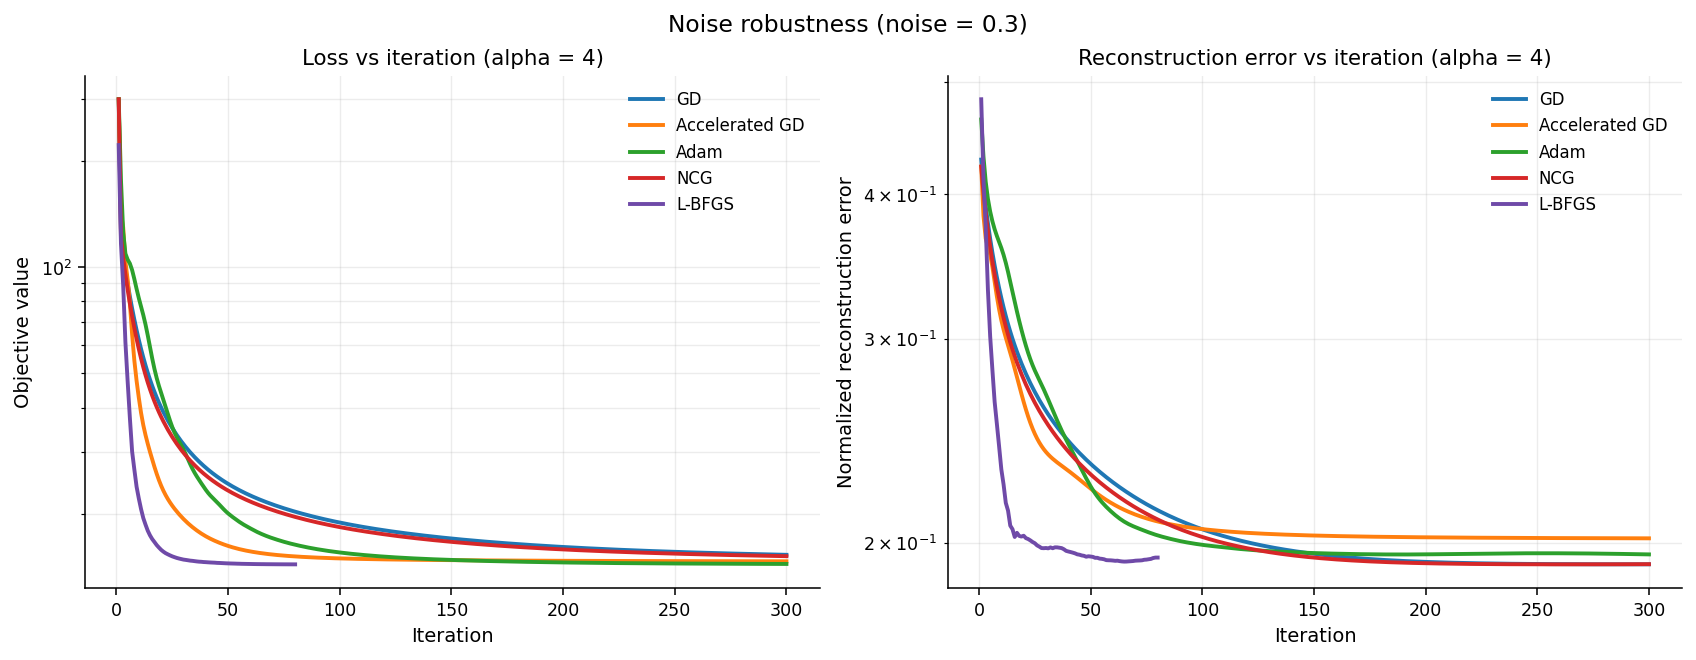

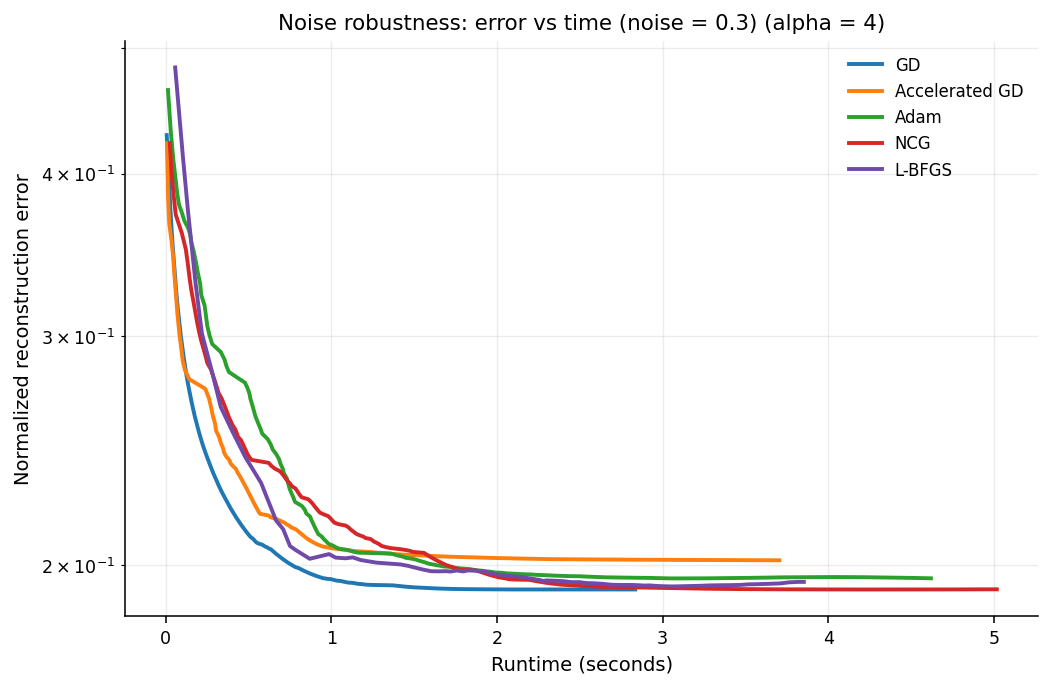

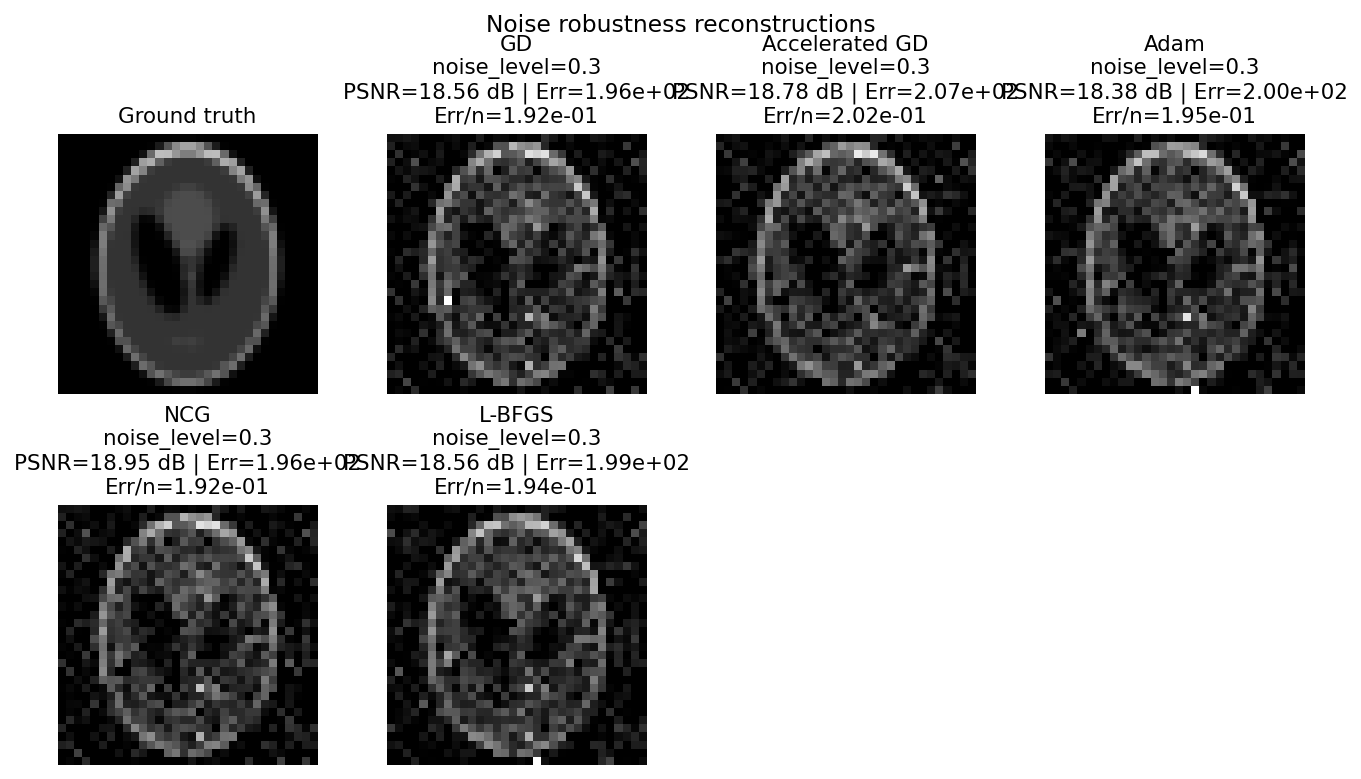

,label,method,psnr_db,final_reconstruction_error,normalized_final_reconstruction_error
0,GD / noise_level=0.3,GD,18.555937,196.226761,0.191628
1,Accelerated GD / noise_level=0.3,Accelerated GD,18.783283,206.627518,0.201785
2,Adam / noise_level=0.3,Adam,18.376303,200.130539,0.195440
3,NCG / noise_level=0.3,NCG,18.946245,196.278412,0.191678
4,L-BFGS / noise_level=0.3,L-BFGS,18.556993,198.876465,0.194215


,method,model,loss,initialization,alpha,noise_level,final_loss,final_reconstruction_error,psnr_db,runtime_seconds,iterations,success
0,GD,deepinv_random,intensity,spectral,4.0,0.3,15.287210,196.226761,18.555937,2.834982,300,False
1,Accelerated GD,deepinv_random,intensity,spectral,4.0,0.3,14.653271,206.627518,18.783283,3.705855,300,False
2,Adam,deepinv_random,intensity,spectral,4.0,0.3,14.400636,200.130539,18.376303,4.621052,300,False
3,NCG,deepinv_random,intensity,spectral,4.0,0.3,15.150825,196.278412,18.946245,5.018725,300,False
4,L-BFGS,deepinv_random,intensity,spectral,4.0,0.3,14.363222,198.876465,18.556993,3.853112,80,False


In [7]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "report_experiments_split").exists():
        sys.path.insert(0, str(candidate))
        break

from report_experiments_split import config, problem, metrics, runners, plotting, common, experiment_configs
import importlib
importlib.reload(config)
importlib.reload(problem)
importlib.reload(metrics)
importlib.reload(runners)
importlib.reload(plotting)
importlib.reload(common)
importlib.reload(experiment_configs)
from report_experiments_split.experiments import noise_robustness

importlib.reload(noise_robustness)

outputs = noise_robustness.run()
summary = outputs.get('summary')
summary
